In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os


SAVE_DIR = "../evaluation/plots/heart"
os.makedirs(SAVE_DIR, exist_ok=True)

df=pd.read_csv('../data/processed/heart/heart_processed.csv')
df.head()

,age,trestbps,chol,prognosis
0,63,145.0,233.0,0
1,67,160.0,286.0,1
2,67,120.0,229.0,1
3,37,130.0,250.0,0
4,41,130.0,204.0,0


In [3]:
#dataset inf
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        920 non-null    int64  
 1   trestbps   920 non-null    float64
 2   chol       920 non-null    float64
 3   prognosis  920 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.9 KB


,age,trestbps,chol,prognosis
count,920.000000,920.000000,920.000000,920.000000
mean,53.510870,131.995652,199.908696,0.553261
std,9.424685,18.451300,109.040171,0.497426
min,28.000000,0.000000,0.000000,0.000000
25%,47.000000,120.000000,177.750000,0.000000
50%,54.000000,130.000000,223.000000,1.000000
75%,60.000000,140.000000,267.000000,1.000000
max,77.000000,200.000000,603.000000,1.000000


In [4]:
df.isnull().sum()

age          0
trestbps     0
chol         0
prognosis    0
dtype: int64

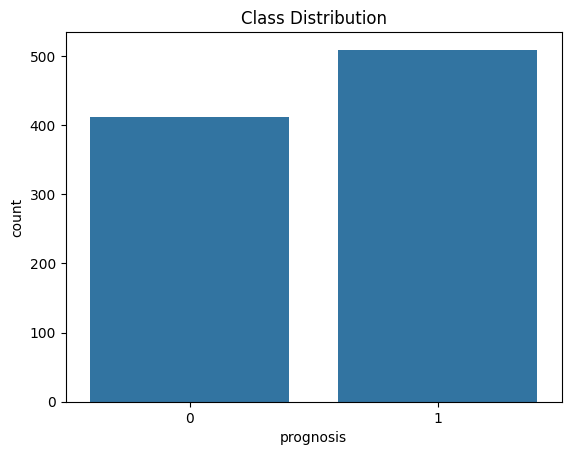

In [5]:
#class distribution
sns.countplot(x='prognosis',data=df)
plt.title('Class Distribution')
plt.savefig(f'{SAVE_DIR}/class_distribution_heart.png',dpi=300,bbox_inches='tight')
plt.show()

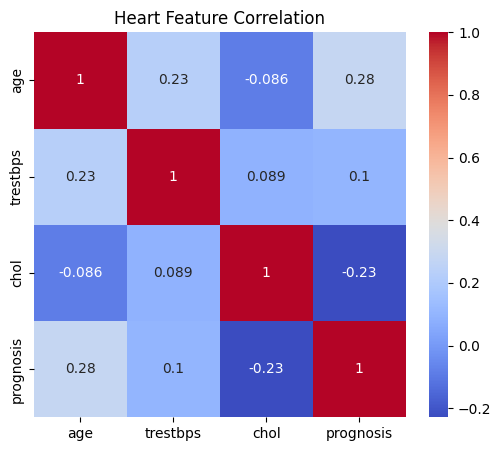

In [6]:
#correlation
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Heart Feature Correlation")

plt.savefig(f'{SAVE_DIR}/correlation_heatmap.png',dpi=300,bbox_inches='tight')
plt.show()

### Correlation Analysis – Heart Dataset

- Age shows a weak to moderate positive correlation with heart disease, indicating increased risk with advancing age.
- Resting blood pressure and cholesterol exhibit weak linear correlations with the outcome.
- The absence of strong linear correlations suggests that heart disease risk arises from complex, non-linear interactions rather than single biomarkers.


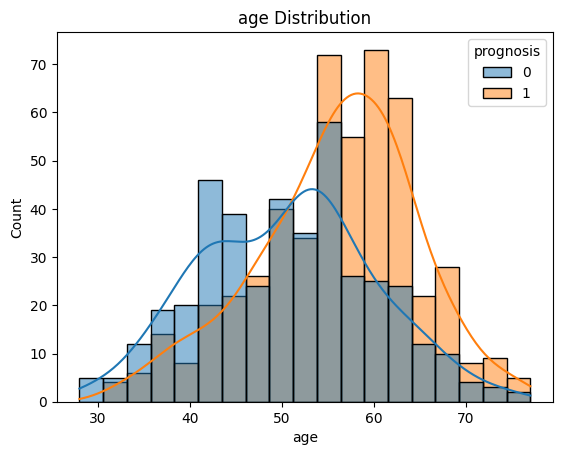

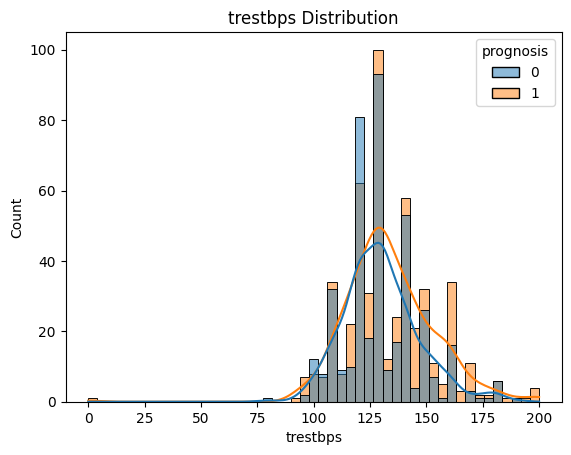

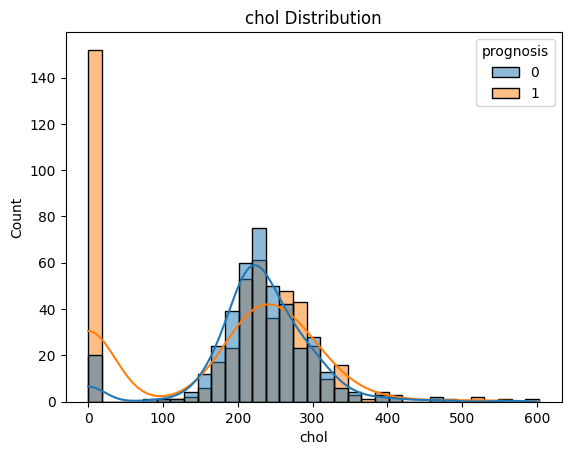

In [7]:
for col in df.columns:
    if col !="prognosis":
        plt.figure()
        sns.histplot(data=df,x=col,hue='prognosis',kde=True)
        plt.title(f'{col} Distribution')

        plt.savefig(f'{SAVE_DIR}/{col}_distribution.png',dpi=300,bbox_inches='tight')
        plt.show()

### Feature Distribution – Age (Heart Dataset)

- Heart disease patients tend to be older on average, with the distribution shifted toward higher age values.
- Substantial overlap exists between heart disease and non-disease groups, indicating that age alone is insufficient for diagnosis.
- Age acts as a supporting risk factor rather than a primary indicator.



### Feature Distribution – Resting Blood Pressure

- Resting blood pressure distributions largely overlap between heart disease and non-disease groups.
- The heart disease group exhibits a slightly wider spread toward higher blood pressure values.
- This suggests that blood pressure contributes to cardiovascular risk but is insufficient as a standalone diagnostic feature.



### Feature Distribution – Resting Blood Pressure

- Resting blood pressure distributions largely overlap between heart disease and non-disease groups.
- The heart disease group exhibits a slightly wider spread toward higher blood pressure values.
- This suggests that blood pressure contributes to cardiovascular risk but is insufficient as a standalone diagnostic feature.



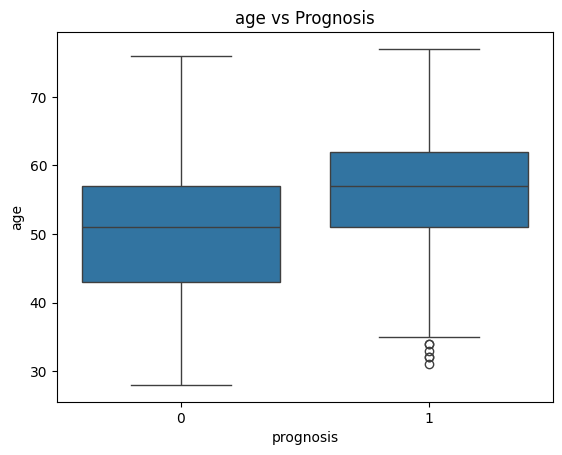

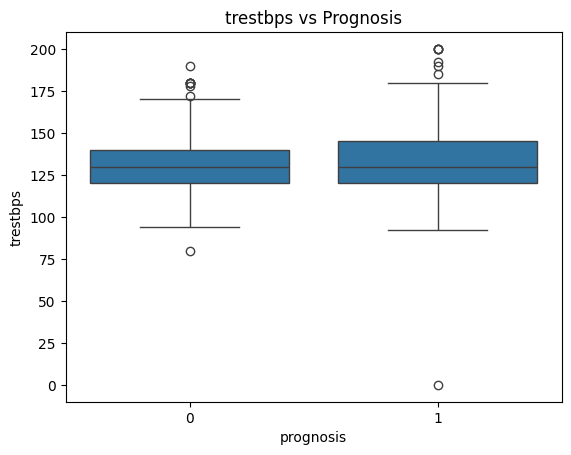

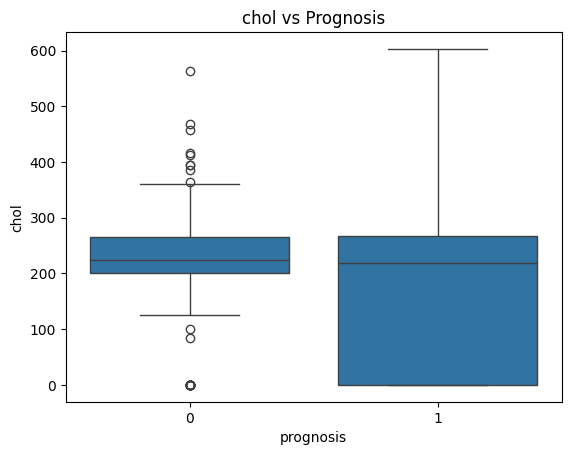

In [8]:
for col in df.columns:
    if col != "prognosis":
        plt.figure()
        sns.boxplot(x="prognosis", y=col, data=df)
        plt.title(f"{col} vs Prognosis")

        plt.savefig(f"{SAVE_DIR}/{col}_boxplot.png",
                    dpi=300,
                    bbox_inches="tight")
        plt.show()


### Boxplot Analysis – Age vs Prognosis (Heart)

- Heart disease patients exhibit a higher median age compared to non-disease individuals.
- Considerable overlap between the two groups indicates that age alone cannot reliably distinguish heart disease.
- The presence of younger outliers suggests that heart disease may occur across a wide age range.


### Boxplot Analysis – Resting Blood Pressure vs Prognosis

- Median resting blood pressure values are similar between heart disease and non-disease groups.
- The heart disease group shows slightly greater variability and higher extreme values.
- These findings suggest that resting blood pressure is a contributing risk factor but lacks strong standalone discriminative power.


### Boxplot Analysis – Cholesterol vs Prognosis

- Cholesterol levels demonstrate substantial overlap between heart disease and non-disease groups.
- The heart disease group exhibits greater variability, reflecting heterogeneous lipid profiles.
- These observations indicate that cholesterol alone is insufficient for heart disease classification.
